In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
# | tags: [parameters]
subject_id = "170"

In [4]:
from pathlib import Path
import os
import mne
import matplotlib.pyplot as plt
import numpy as np
import mne
from mne.preprocessing import annotate_amplitude
from spectral.annotation import (
run_pyprep_cleaning,
annotate_bads_to_raw,
    apply_potato_to_raw
)
from spectral.preproc import (
    load_data,

)
from spectral.utils import ProjectPaths, print_timestamp, load_config

#mne.viz.set_browser_backend("matplotlib")
# mne.viz.set_browser_backend("qt")
mne.set_config("MNE_BROWSER_THEME", "light")

# Initialize paths for your subject
paths = ProjectPaths(subject_id)

# Create all directories
paths.create_directories()

# Print paths to verify
print_timestamp("Setting up project paths")
paths.show()

Created directories for sub-170
Project root: /Users/daniel/PhD/Projects/psd-paths
Setting up project paths: 2025-11-28 08:54:22
────────────────────────────────────────────────────────────
Paths for sub-170
Project Root: /Users/daniel/PhD/Projects/psd-paths
────────────────────────────────────────────────────────────
  analysis     : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/analysis
  data         : /Users/daniel/PhD/Projects/psd-paths/data/bids/sub-170
  epochs       : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/epochs
  figures      : /Users/daniel/PhD/Projects/psd-paths/outputs/figures/sub-170
  ica          : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/analysis/ica
  logs         : /Users/daniel/PhD/Projects/psd-paths/data/logs
  outputs      : /Users/daniel/PhD/Projects/psd-paths/outputs
  preprocessed : /Users/daniel/PhD/Projects/psd-paths/data/derrivatives/sub-170/preprocessed
  processing   : /Users/daniel/PhD/Project

Loading BrainVision data from: sub-170_ses-01_task-RESTING_eeg.vhdr
Extracting parameters from /Users/daniel/PhD/Projects/psd-paths/data/bids/sub-170/ses-01/eeg/sub-170_ses-01_task-RESTING_eeg.vhdr...
Setting channel info structure...
Reading 0 ... 314879  =      0.000 ...   314.879 secs...
Loaded 258 channels, 314.9 seconds of data
Identified ECG channels: ['ECG']
Removed 'VREF' channel.
Applying GSN-HydroCel-256 montage...
Including 0 SSP projectors from raw file
Running ECG SSP computation
Using channel ECG to identify heart beats.
Setting up band-pass filter from 5 - 35 Hz

FIR filter parameters
---------------------
Designing a two-pass forward and reverse, zero-phase, non-causal bandpass filter:
- Windowed frequency-domain design (firwin2) method
- Hann window
- Lower passband edge: 5.00
- Lower transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 4.75 Hz)
- Upper passband edge: 35.00 Hz
- Upper transition bandwidth: 0.50 Hz (-12 dB cutoff frequency: 35.25 Hz)
- Filter length:

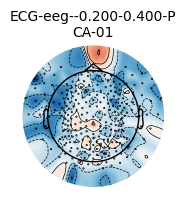

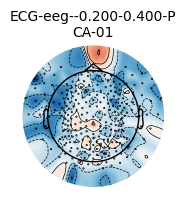

In [9]:
import mne
raw = load_data(subject_id, data_path=paths.data)

# Correct way to call the function
ecg_projs, ecg_events = mne.preprocessing.compute_proj_ecg(
    raw, 
    n_grad=0, 
    n_mag=0, 
    n_eeg=1,       # Number of vectors (1 is usually enough for ECG)
    reject=None    # Set rejection if needed, or None to use all detected beats
)

# 3. Add the projections to the raw data
raw.add_proj(ecg_projs)

# 4. (Optional but Recommended) View the artifact map before applying
mne.viz.plot_projs_topomap(ecg_projs, raw.info)

In [12]:
# 1. Run ICA on your current data (with the bad channels already dropped/marked)
# Using 'picard' is good, but 'fastica' is also very robust for blinks/ECG
fline = [50, 100]  # Line noise frequencies

ica = mne.preprocessing.ICA(n_components=0.99, method='picard', random_state=97)

# 2. Fit to your data (filter it first if possible to help separation)
raw_for_ica = raw.copy().filter(1.0, 100.0).notch_filter(freqs=[fline], method="fir",   picks=['eeg', 'ecg'])
ica.fit(raw_for_ica)

# 3. Visualize the sources to find the Real ECG and the Real Blinks
ica.plot_sources(raw_for_ica )

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 1e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 100.00 Hz
- Upper transition bandwidth: 25.00 Hz (-6 dB cutoff frequency: 112.50 Hz)
- Filter length: 3301 samples (3.301 s)

Filtering raw data in 1 contiguous segment
Setting up band-stop filter

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandstop filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower transition bandwidth: 0.50 Hz
- Upper transition bandwidth: 0.50 Hz
- Filter length: 6601 samples (6.601 s)

Fitting ICA to d

RuntimeError: One PCA component captures most of the explained variance (99.80639234645962%), your threshold results in 1 component. You should select a higher value.

In [9]:
# 1. Visualize the average of the "ECG" epochs
ecg_evoked = raw.average()
ecg_evoked.plot(titles="Average 'ECG' Epoch (Is it a spike or a wave?)")

AttributeError: 'RawBrainVision' object has no attribute 'average'